
# Avaliação Prática — Fundamentos de Pandas (Módulo 3)

Esta avaliação contém **10 questões** de nível introdutório sobre **Pandas** e **análise de dados**.
O foco é demonstrar domínio das operações básicas de **importação**, **inspeção** e **manipulação simples** de DataFrames.

**Instruções gerais:**
- Responda **apenas** nas células de código logo abaixo de cada enunciado.
- Execute a célula **Setup** antes de começar.
- Utilize o arquivo CSV fornecido: **`avaliacao_empresa.csv`** (na mesma pasta deste notebook).

In [1]:

# Setup (execute esta célula primeiro — não alterar)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 30)
print("Ambiente pronto.")


Ambiente pronto.


### Questão 1) Importe o arquivo CSV e crie um DataFrame chamado `df`.

In [4]:
df= pd.read_csv("avaliacao_empresa.csv")


#  Insira o código que importa o .csv e o transforma em DataFrame (há um método que faz as duas coisas)
# Dica: use pd.read_csv(...)
# CAMINHO = "avaliacao_empresa.csv"
# df = ...

### Questão 2) Mostre os **5 primeiros** elementos do DataFrame.

In [5]:
df.head()
# Escreva o comando para visualizar as 5 primeiras linhas do DataFrame
# ...

,id_funcionario,nome,departamento,turno,cidade,data,vendas_qtd,ticket_medio,faturamento,custo,lucro,horas_trabalhadas,salario
0,2,Bruno,Operacoes,Tarde,Campinas,2025-01-01,56,975.0,54600.0,41435.15,13164.85,166,8086
1,3,Carla,TI,Noite,Sao Paulo,2025-01-08,50,415.0,20750.0,10791.38,9958.62,142,8703
2,4,Diego,Vendas,Manha,Campinas,2025-01-15,55,107.0,5885.0,4287.17,1597.83,130,8221
3,5,Elaine,Operacoes,Tarde,Sao Paulo,2025-01-22,11,755.0,8305.0,4328.67,3976.33,147,4954
4,6,Fabio,TI,Noite,Campinas,2025-01-29,44,456.0,20064.0,11597.60,8466.40,158,6378


### Questão 3) Exiba as **informações gerais** do DataFrame (tipos de dados e nulos).

In [6]:
df.info()

# Use o método apropriado para ver tipos de dados e contagem de nulos
# ...

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_funcionario     26 non-null     int64  
 1   nome               26 non-null     str    
 2   departamento       26 non-null     str    
 3   turno              26 non-null     str    
 4   cidade             26 non-null     str    
 5   data               26 non-null     str    
 6   vendas_qtd         26 non-null     int64  
 7   ticket_medio       26 non-null     float64
 8   faturamento        26 non-null     float64
 9   custo              26 non-null     float64
 10  lucro              26 non-null     float64
 11  horas_trabalhadas  26 non-null     int64  
 12  salario            26 non-null     int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 3.6 KB


### Questão 4) Mostre o **formato (linhas, colunas)** e a **lista de colunas** do DataFrame.

In [11]:

print(df.shape)
print(df.columns)


# Mostre df.shape e df.columns
# ...

(26, 13)
Index(['id_funcionario', 'nome', 'departamento', 'turno', 'cidade', 'data',
       'vendas_qtd', 'ticket_medio', 'faturamento', 'custo', 'lucro',
       'horas_trabalhadas', 'salario'],
      dtype='str')


### Questão 5) Exiba as **estatísticas descritivas** das colunas numéricas (média, min, max, etc.).

In [15]:
df.describe()
# Utilize o método para estatísticas descritivas
# ...

,id_funcionario,vendas_qtd,ticket_medio,faturamento,custo,lucro,horas_trabalhadas,salario
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,9.115385,36.230769,704.461538,24709.769231,16113.651154,8596.118077,161.384615,6528.846154
std,5.826333,16.307808,357.249966,18055.721968,13710.279075,5829.027283,21.183157,1829.020824
min,1.000000,7.000000,107.000000,3690.000000,2035.920000,1192.560000,121.000000,3274.000000
25%,4.250000,27.500000,404.500000,12385.250000,6811.280000,4104.262500,148.500000,4988.500000
50%,7.500000,40.500000,709.000000,20244.000000,10845.565000,7569.950000,160.000000,6523.500000
75%,13.750000,49.750000,944.500000,34814.500000,23857.580000,10760.152500,173.500000,8214.000000
max,20.000000,57.000000,1384.000000,67816.000000,50905.520000,23620.960000,199.000000,9297.000000


### Questão 6) Selecione apenas as colunas `nome` e `departamento` e mostre as **5 primeiras** linhas.

In [21]:
df[['nome','departamento']].head()
# Selecione as colunas solicitadas e mostre 5 primeiras linhas
# ...

,nome,departamento
0,Bruno,Operacoes
1,Carla,TI
2,Diego,Vendas
3,Elaine,Operacoes
4,Fabio,TI


### Questão 7) Filtre os registros do **turno 'Noite'** e **conte** quantos registros existem.

In [71]:
tn= df['turno']=='Noite'
tn.sum()




# Filtre df['turno'] == 'Noite' e conte as linhas resultantes
# ...

np.int64(9)

### Questão 8) O código abaixo converte as datas de texto para data e em seguida cria uma coluna mês para os dados.
Mostre as **5 primeiras** linhas de `df[['data','mes']]`.

In [32]:
df['data']=pd.to_datetime(df['data'],errors='coerce')
df['mes']=df['data'].dt.to_period('M').astype(str)
df[['data','mes']].head()

#Insira o seu código aqui

,data,mes
0,2025-01-01,2025-01
1,2025-01-08,2025-01
2,2025-01-15,2025-01
3,2025-01-22,2025-01
4,2025-01-29,2025-01


### Questão 9) O código abaixo agrupa e soma os valores por mes no DataFrame fat.
Mostre os **3 meses** com maior faturamento.

In [56]:
fat = df.groupby('mes',as_index=False)['faturamento'].sum()
fat.nlargest(3, 'faturamento')

,mes,faturamento
5,2025-06,135267.0
2,2025-03,113759.0
0,2025-01,109604.0


### Questão 10) Calcule a **média de salário por departamento** e mostre em **ordem decrescente**.

In [58]:
salarios_por_departamento = df.groupby('departamento',as_index=False)['salario']
sd =df.groupby('departamento',as_index=False)['salario'].mean().sort_values('salario',ascending=False)
sd
#Insira seu código aqui

,departamento,salario
1,TI,6795.444444
2,Vendas,6554.875000
0,Operacoes,6239.111111



---
## Extra (não avaliativo) — Demonstração de visualização

O gráfico abaixo mostra a **distribuição do faturamento por mês e por departamento** (barras empilhadas).  
**Ação do aluno:** **apenas execute** a célula para observar o resultado e refletir sobre variações por mês e por área.


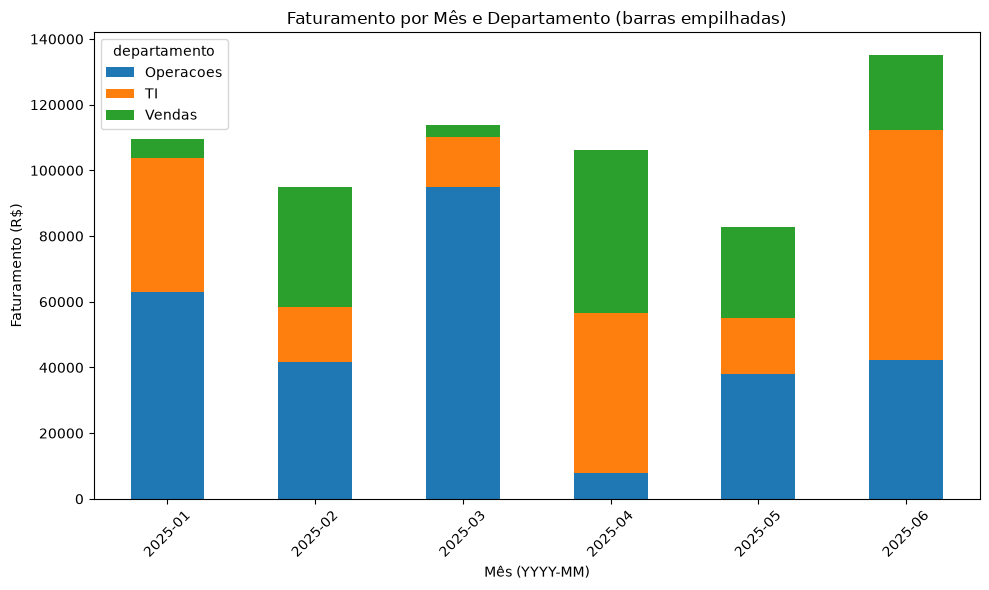

In [59]:

# ▶️ Execute esta célula (não alterar o código)
# Pré-requisitos: df já carregado; coluna 'data' convertida; coluna 'mes' criada (Questões 1 e 8).
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df['mes'] = df['data'].dt.to_period('M').astype(str)

fat_mes_dep = df.groupby(['mes','departamento'], as_index=False)['faturamento'].sum()
pivot = fat_mes_dep.pivot(index='mes', columns='departamento', values='faturamento').fillna(0)

ax = pivot.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_title("Faturamento por Mês e Departamento (barras empilhadas)")
ax.set_xlabel("Mês (YYYY-MM)")
ax.set_ylabel("Faturamento (R$)")
import matplotlib.pyplot as plt
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
